# 2. The labels

How every label was made. Everything is recomputed from stored files, so the notebook
runs offline in about 2 minutes.


In [1]:
import os, csv, json, collections
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

from nb_style import (ROOT, p, TRAIN_COLOR, VAL_COLOR, USABLE_C, UNUSABLE_C,
                      plot_confusion, verify, verify_summary)

def rows(path):
    with open(path, newline="", encoding="utf-8") as fh:
        return list(csv.DictReader(fh))

## 1. Expert labelling

The domain expert graded slides in a purpose-built web app. He later re-graded 50 slides
blind. That self-agreement figure, recomputed below, is the ceiling for any model scored
against his labels.


In [2]:
human = rows(p("review_tool", "results", "final_clean_dataset_20260802.csv"))
print("labelling batches:", dict(collections.Counter(r["batch"] for r in human)))

orig = {r["image_id"]: r["label"]
        for r in rows(p("review_tool", "results", "expert_original500_20260727.csv"))}
recode = {r["image_id"]: r["label"]
          for r in rows(p("review_tool", "results", "expert_recode50_20260727.csv"))}
shared = [k for k in recode if k in orig]
agree = sum(1 for k in shared if orig[k] == recode[k])
from sklearn.metrics import cohen_kappa_score
kappa = cohen_kappa_score([orig[k] for k in shared], [recode[k] for k in shared])
print(f"re-coded slides: {len(shared)}   agreement {agree}/{len(shared)} "
      f"= {agree/len(shared)*100:.0f}%   Cohen kappa = {kappa:.3f}")
print("interpretation: 'substantial' (Landis & Koch) — and a ceiling for ANY labeller "
      "judged against these labels: the expert disagrees with himself on ~6% of slides.")

labelling batches: {'original': 373, 'topup_mining': 250, 'topup': 224}


re-coded slides: 50   agreement 47/50 = 94%   Cohen kappa = 0.735
interpretation: 'substantial' (Landis & Koch) — and a ceiling for ANY labeller judged against these labels: the expert disagrees with himself on ~6% of slides.


## 2. The rubric

Rubric v1.0 (frozen 12 August 2026, signed off by the expert). A slide is usable if it has
at least one stretch of roughly five or more adjacent villus epithelial cells with apical
and basal surfaces visible and staining readable. No staining is fine (recorded as "not
expressed"). Crypt-to-villus transition zones do not count. The figures below show a
usable slide with its features annotated and a hard slide.


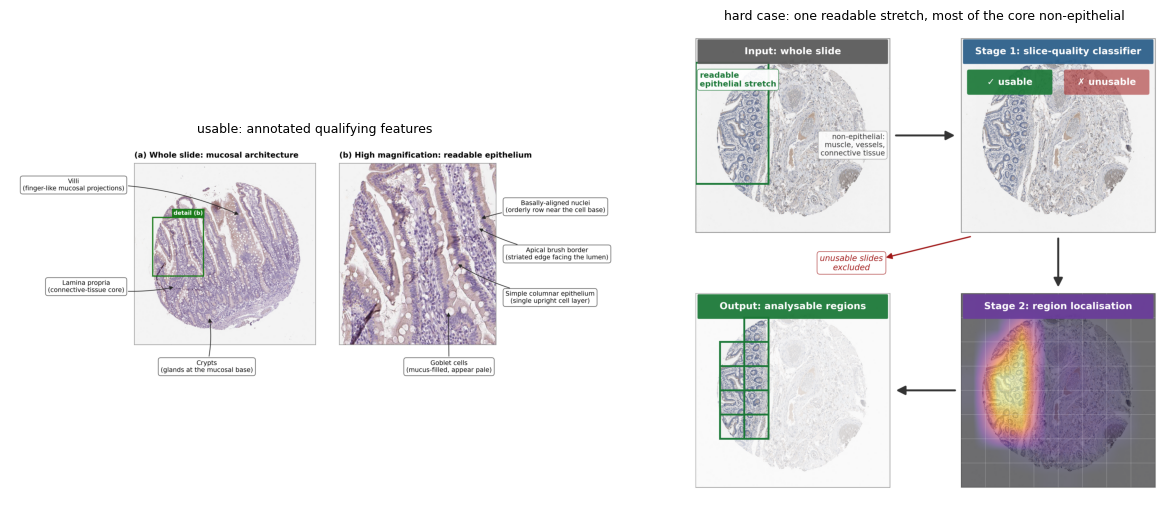

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(12.5, 5.2))
for ax, (f, t) in zip(axes, [("figure_good.png", "usable: annotated qualifying features"),
                             ("figure2.png", "hard case: one readable stretch, most of the core non-epithelial")]):
    ax.imshow(Image.open(p("dissertation", "figures", f)))
    ax.set_title(t, fontsize=9); ax.axis("off")
fig.tight_layout(); plt.show()

## 3. Can a vision-language model apply the rubric?

Several VLMs were tested on 120 held-out expert-labelled slides (60 usable, 60 unusable).
A pathology-specific VLM failed. The general models all scored close to the expert's own
self-agreement, so the limit is the ambiguity of the task rather than the models.


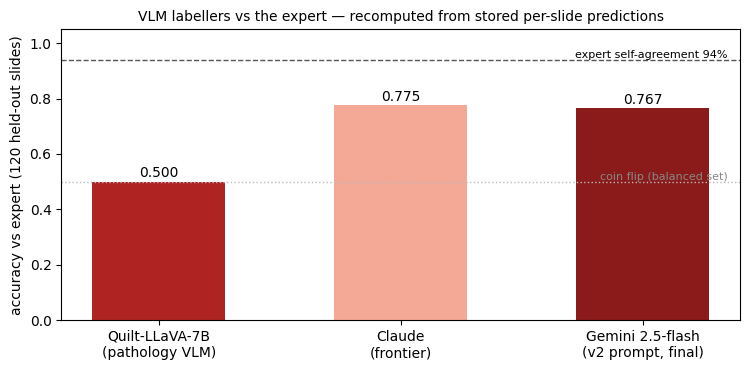

(Gemini leg scored on 120 slides; note the Quilt bar is exactly chance — it answered 'usable' 120/120 times, unusable recall 0.000)


In [4]:
def acc_of(path, true_k, pred_k):
    r = [x for x in rows(path) if x[pred_k] in ("usable", "unusable")]
    return sum(1 for x in r if x[true_k] == x[pred_k]) / len(r), len(r)

models = {}
models["Quilt-LLaVA-7B\n(pathology VLM)"], _ = acc_of(p("probe", "quilt_probe_results.csv"), "true_label", "pred")
models["Claude\n(frontier)"], _ = acc_of(p("probe", "vlm_probe_results_claude_claude_code_default.csv"), "true_label", "pred")
models["Gemini 2.5-flash\n(v2 prompt, final)"], n120 = acc_of(p("probe", "fewshot_preds_test_base.csv"), "true", "pred")

fig, ax = plt.subplots(figsize=(7.6, 3.8))
names = list(models); vals = [models[k] for k in names]
bars = ax.bar(names, vals, color=[UNUSABLE_C, TRAIN_COLOR, VAL_COLOR], width=0.55)
ax.axhline(0.94, color="#555", ls="--", lw=1)
ax.text(2.35, 0.945, "expert self-agreement 94%", fontsize=8, ha="right")
ax.axhline(0.5, color="#bbb", ls=":", lw=1)
ax.text(2.35, 0.505, "coin flip (balanced set)", fontsize=8, ha="right", color="#888")
for b, v in zip(bars, vals):
    ax.text(b.get_x() + b.get_width()/2, v + 0.015, f"{v:.3f}", ha="center", fontsize=10)
ax.set_ylim(0, 1.05); ax.set_ylabel("accuracy vs expert (120 held-out slides)")
ax.set_title("VLM labellers vs the expert — recomputed from stored per-slide predictions", fontsize=10)
fig.tight_layout(); plt.show()
print(f"(Gemini leg scored on {n120} slides; note the Quilt bar is exactly chance — "
      f"it answered 'usable' 120/120 times, unusable recall 0.000)")

## 4. The machine labeller

Single prompts plateaued at about 0.78 accuracy, so the final labeller votes across seven
Gemini 2.5 members (five flash, two pro). Three cheap members run on every slide and only
disagreements go to the full panel. A slide is unusable if at least 5 of 7 say so.
Held-out accuracy is 0.850, recomputed below, at $91 for 5,900 slides.


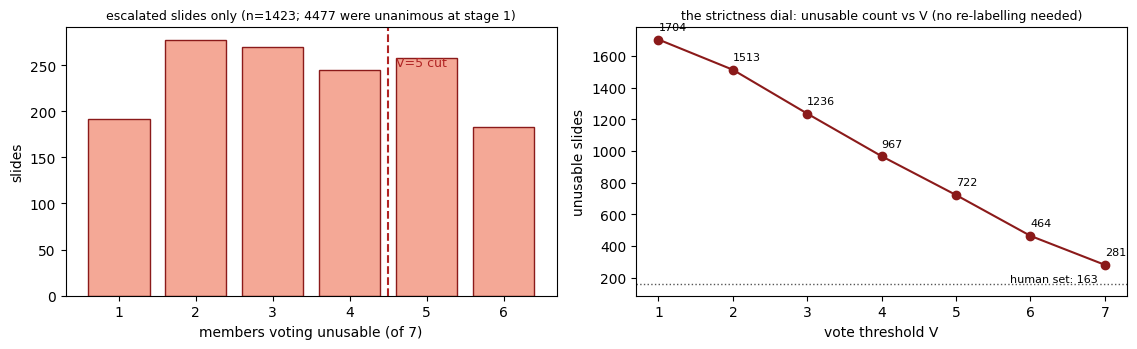

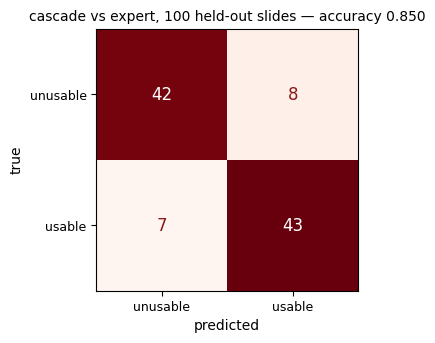

In [5]:
ens = [r for r in rows(p("models", "vlm_labels", "ensemble_cascade_labels.csv"))
       if r["label"] in ("usable", "unusable")]
s2 = [r for r in ens if r["stage"] == "2"]
votes = [int(r["unusable_votes"]) for r in s2 if str(r["unusable_votes"]).isdigit()]
hist = collections.Counter(votes)

fig, axes = plt.subplots(1, 2, figsize=(11.5, 3.6))
axes[0].bar(sorted(hist), [hist[k] for k in sorted(hist)], color=TRAIN_COLOR,
            edgecolor=VAL_COLOR)
axes[0].axvline(4.5, color=UNUSABLE_C, ls="--")
axes[0].text(4.6, max(hist.values())*0.9, "V=5 cut", color=UNUSABLE_C, fontsize=9)
axes[0].set_xlabel("members voting unusable (of 7)"); axes[0].set_ylabel("slides")
axes[0].set_title(f"escalated slides only (n={len(s2)}; "
                  f"{len(ens)-len(s2)} were unanimous at stage 1)", fontsize=9)

vs = range(1, 8)
n_stage1_unus = sum(1 for r in ens if r["stage"] != "2" and r["label"] == "unusable")
dial = [n_stage1_unus + sum(1 for v in votes if v >= V) for V in vs]
axes[1].plot(list(vs), dial, "o-", color=VAL_COLOR)
for V, d in zip(vs, dial):
    axes[1].annotate(str(d), (V, d), textcoords="offset points", xytext=(0, 7), fontsize=8)
axes[1].axhline(163, color="#555", ls=":", lw=1)
axes[1].text(6.9, 175, "human set: 163", fontsize=8, ha="right")
axes[1].set_xlabel("vote threshold V"); axes[1].set_ylabel("unusable slides")
axes[1].set_title("the strictness dial: unusable count vs V (no re-labelling needed)", fontsize=9)
fig.tight_layout(); plt.show()

# held-out accuracy of the shipped cascade, recomputed
val_truth = {r["image_id"]: r["label"] for r in rows(p("probe", "prompt_val.csv"))}
val_pred = [(val_truth[r["source_image"]], r["label"])
            for r in rows(p("probe", "ensemble_cascade_val.csv"))
            if r["source_image"] in val_truth]
acc = sum(1 for t, pr in val_pred if t == pr) / len(val_pred)
cm = np.zeros((2, 2), int)
for t, pr in val_pred:
    cm[int(t == "usable"), int(pr == "usable")] += 1
plot_confusion(cm, f"cascade vs expert, 100 held-out slides — accuracy {acc:.3f}")
plt.show()

## 5. Example machine labels

Four contested slides with the verdict and how the seven members voted.


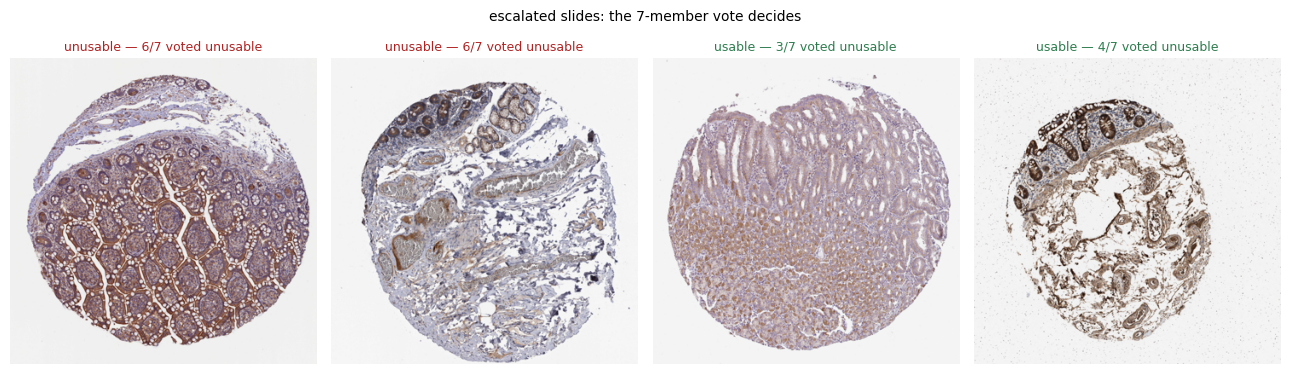

In [6]:
import random
random.seed(7)
sample = random.sample([r for r in s2], 4)
fig, axes = plt.subplots(1, 4, figsize=(13, 3.9))
for ax, r in zip(axes, sample):
    with Image.open(p("data_bulk", "images", r["source_image"])) as im:
        im.thumbnail((360, 360)); ax.imshow(im)
    lab = r["label"]
    ax.set_title(f"{lab} — {r['unusable_votes']}/7 voted unusable",
                 fontsize=9, color=(USABLE_C if lab == "usable" else UNUSABLE_C))
    ax.axis("off")
fig.suptitle("escalated slides: the 7-member vote decides", fontsize=10)
fig.tight_layout(); plt.show()

## 6. Check against the research log


In [7]:
verify("intra-rater agreement", agree, 47, source="LOG/finding, agreement export 2026-07-27")
verify("intra-rater kappa", round(float(kappa), 3), 0.735, source="LOG 2026-07-27")
verify("Quilt accuracy (null result)", round(models["Quilt-LLaVA-7B\n(pathology VLM)"], 3),
       0.5, source="LOG 2026-08-09")
verify("Claude 120-test accuracy", round(models["Claude\n(frontier)"], 3), 0.775,
       source="LOG 2026-08-14")
verify("Gemini v2 120-test accuracy", round(models["Gemini 2.5-flash\n(v2 prompt, final)"], 3),
       0.767, source="LOG 2026-08-16")
verify("ensemble held-out accuracy", round(acc, 3), 0.85, source="LOG 2026-08-17")
verify("ensemble val confusion", cm.tolist(), [[42, 8], [7, 43]], source="LOG 2026-08-17")
verify("escalated (stage-2) slides", len(s2), 1423, source="LOG 2026-08-17")
verify("V=5 unusable count", dial[4], 722, source="LOG 2026-08-17")
verify("V=4 unusable count", dial[3], 967, source="LOG 2026-08-17")
verify("V=3 unusable count", dial[2], 1236, source="LOG 2026-08-17")
verify_summary()

  ✓  intra-rater agreement: computed 47  expected 47   [LOG/finding, agreement export 2026-07-27]
  ✓  intra-rater kappa: computed 0.735  expected 0.735   [LOG 2026-07-27]
  ✓  Quilt accuracy (null result): computed 0.5  expected 0.5   [LOG 2026-08-09]
  ✓  Claude 120-test accuracy: computed 0.775  expected 0.775   [LOG 2026-08-14]
  ✓  Gemini v2 120-test accuracy: computed 0.767  expected 0.767   [LOG 2026-08-16]
  ✓  ensemble held-out accuracy: computed 0.85  expected 0.85   [LOG 2026-08-17]
  ✓  ensemble val confusion: computed [[42, 8], [7, 43]]  expected [[42, 8], [7, 43]]   [LOG 2026-08-17]
  ✓  escalated (stage-2) slides: computed 1423  expected 1423   [LOG 2026-08-17]
  ✓  V=5 unusable count: computed 722  expected 722   [LOG 2026-08-17]
  ✓  V=4 unusable count: computed 967  expected 967   [LOG 2026-08-17]
  ✓  V=3 unusable count: computed 1236  expected 1236   [LOG 2026-08-17]

VERIFICATION: 11/11 checks passed
